In [1]:
# Cell 1: Setup and Data Loading
print("=== Starting PPG Feature-Family Ablation Pipeline ===")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import skew, kurtosis, entropy
from scipy.interpolate import interp1d
from scipy.signal import welch
import neurokit2 as nk
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import xgboost as xgb
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    has_lightgbm = True
except ImportError:
    has_lightgbm = False

# Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

csv_path = "data/real/glucosense_r_dataset_2026-09-04.csv"
sampling_rate = 50  # 50 Hz

# Handle numpy 2.0 compatibility for integration
trapz_fn = getattr(np, 'trapezoid', getattr(np, 'trapz', None))

print(f"✓ Imports complete. LightGBM available: {has_lightgbm}")


=== Starting PPG Feature-Family Ablation Pipeline ===
✓ Imports complete. LightGBM available: True


In [2]:
# Cell 2: Feature Extraction Pipeline across Groups A, B, C, D

def extract_pulse_morphology(sig, sr=50):
    """Group A: PPG Morphology features from individual pulse cycles & APG landmarks."""
    try:
        cleaned = nk.ppg_clean(sig, sampling_rate=sr)
        peaks_dict = nk.ppg_findpeaks(cleaned, sampling_rate=sr)
        peaks = peaks_dict.get("PPG_Peaks", [])
        if len(peaks) < 3:
            return {}
        
        # Derivatives
        vpg = np.gradient(cleaned)  # 1st deriv
        apg = np.gradient(vpg)      # 2nd deriv
        jpg = np.gradient(apg)      # 3rd deriv
        
        # APG landmarks (a, b, c, d, e)
        a_vals, b_vals = [], []
        p2p_vals, amp_vals = [], []
        sys_slopes = []
        
        for i in range(len(peaks) - 1):
            p1, p2 = peaks[i], peaks[i+1]
            pulse = cleaned[p1:p2]
            if len(pulse) < 5:
                continue
            
            p2p_vals.append(float(np.ptp(pulse)))
            amp_vals.append(float(np.max(pulse) - np.min(pulse)))
            
            # APG landmarks in cycle
            apg_cycle = apg[p1:p2]
            a_idx = np.argmax(apg_cycle)
            a_val = apg_cycle[a_idx]
            
            b_val = np.min(apg_cycle[a_idx:]) if a_idx < len(apg_cycle)-1 else 0
            
            a_vals.append(float(a_val))
            b_vals.append(float(b_val))
            
            # Systolic slope
            min_idx = np.argmin(pulse[:np.argmax(pulse)+1]) if np.argmax(pulse) > 0 else 0
            max_idx = np.argmax(pulse)
            if max_idx > min_idx:
                sys_slopes.append(float((pulse[max_idx] - pulse[min_idx]) / ((max_idx - min_idx) / sr)))

        mean_a = np.mean(a_vals) if a_vals else 1e-5
        mean_b = np.mean(b_vals) if b_vals else 0
        
        b_a_ratio = mean_b / mean_a if abs(mean_a) > 1e-5 else 0
        
        return {
            "morph_p2p_mean": float(np.mean(p2p_vals)) if p2p_vals else np.nan,
            "morph_p2p_std": float(np.std(p2p_vals)) if p2p_vals else np.nan,
            "morph_amp_mean": float(np.mean(amp_vals)) if amp_vals else np.nan,
            "morph_apg_a_mean": float(np.mean(a_vals)) if a_vals else np.nan,
            "morph_apg_b_mean": float(np.mean(b_vals)) if b_vals else np.nan,
            "morph_apg_b_a_ratio": float(b_a_ratio),
            "morph_aging_index": float(mean_b / mean_a) if abs(mean_a) > 1e-5 else np.nan,
            "morph_sys_slope_mean": float(np.mean(sys_slopes)) if sys_slopes else np.nan,
            "morph_vpg_max": float(np.max(vpg)),
            "morph_apg_max": float(np.max(apg)),
            "morph_jpg_max": float(np.max(jpg))
        }
    except Exception as e:
        return {}

def extract_hrv_features(sig, sr=50):
    """Group B (HR/PRV Time & Frequency) and Group C (Nonlinear PRV) via NeuroKit2."""
    group_b = {}
    group_c = {}
    try:
        cleaned = nk.ppg_clean(sig, sampling_rate=sr)
        peaks_dict = nk.ppg_findpeaks(cleaned, sampling_rate=sr)
        peaks = peaks_dict.get("PPG_Peaks", [])
        
        if len(peaks) >= 4:
            # PRV Time domain
            try:
                hrv_time = nk.hrv_time(peaks, sampling_rate=sr)
                for col in hrv_time.columns:
                    val = float(hrv_time[col].iloc[0])
                    group_b[f"hrv_{col}"] = val
            except Exception:
                pass
                    
            # PRV Frequency domain
            try:
                hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sr)
                for col in hrv_freq.columns:
                    val = float(hrv_freq[col].iloc[0])
                    group_b[f"hrv_{col}"] = val
            except Exception:
                pass
                
            # Group C: PRV Nonlinear features
            try:
                hrv_non = nk.hrv_nonlinear(peaks, sampling_rate=sr)
                for col in hrv_non.columns:
                    val = float(hrv_non[col].iloc[0])
                    if any(k in col for k in ["SampEn", "ApEn", "FuzzyEn", "LZC", "CD", "DFA"]):
                        group_c[f"nonlin_{col}"] = val
                    else:
                        group_b[f"hrv_{col}"] = val
            except Exception:
                pass
    except Exception as e:
        pass
        
    return group_b, group_c

def extract_targeted_ac_dc_features(sig, sr=50):
    """Group D: Basic Frequency Domain, AC/DC, and Pulse Timing Characteristics."""
    try:
        cleaned = nk.ppg_clean(sig, sampling_rate=sr)
        dc_level = float(np.mean(sig))  # DC component baseline
        ac_amp = float(np.ptp(cleaned)) # AC component amplitude
        ac_dc_ratio = ac_amp / dc_level if dc_level != 0 else 0
        
        # Spectral characteristics via Welch
        freqs, psd = welch(cleaned, fs=sr, nperseg=min(len(cleaned), 256))
        dom_freq = float(freqs[np.argmax(psd)])
        total_power = float(np.sum(psd))
        
        # Spectral entropy
        psd_norm = psd / total_power if total_power > 0 else psd
        psd_norm = psd_norm[psd_norm > 0]
        spec_entropy = float(-np.sum(psd_norm * np.log2(psd_norm))) if len(psd_norm) > 0 else 0
        
        # Pulse cycle timing (average beat)
        peaks_dict = nk.ppg_findpeaks(cleaned, sampling_rate=sr)
        peaks = peaks_dict.get("PPG_Peaks", [])
        
        trapz_func = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
        pulse_area = float(trapz_func(np.maximum(0, cleaned)))
        rise_times, fall_times, widths_50, sys_dia_ratios = [], [], [], []
        
        for i in range(len(peaks)-1):
            p1, p2 = peaks[i], peaks[i+1]
            cycle = cleaned[p1:p2]
            if len(cycle) < 5:
                continue
            
            peak_rel = np.argmax(cycle)
            r_time = peak_rel / sr
            f_time = (len(cycle) - peak_rel) / sr
            rise_times.append(float(r_time))
            fall_times.append(float(f_time))
            
            # Pulse width at 50% height
            half_height = (np.max(cycle) - np.min(cycle)) * 0.5 + np.min(cycle)
            above_half = np.where(cycle >= half_height)[0]
            if len(above_half) > 1:
                widths_50.append(float((above_half[-1] - above_half[0]) / sr))
                
            # Systolic/Diastolic Area ratio
            sys_area = float(trapz_func(cycle[:peak_rel+1]))
            dia_area = float(trapz_func(cycle[peak_rel:]))
            if dia_area > 0:
                sys_dia_ratios.append(sys_area / dia_area)

        return {
            "acdc_ac_amp": ac_amp,
            "acdc_dc_level": dc_level,
            "acdc_ac_dc_ratio": float(ac_dc_ratio),
            "acdc_pulse_total_area": pulse_area,
            "acdc_dominant_freq": dom_freq,
            "acdc_spectral_power": total_power,
            "acdc_spectral_entropy": spec_entropy,
            "acdc_rise_time_mean": float(np.mean(rise_times)) if rise_times else np.nan,
            "acdc_fall_time_mean": float(np.mean(fall_times)) if fall_times else np.nan,
            "acdc_rise_fall_ratio": float(np.mean(rise_times) / np.mean(fall_times)) if fall_times and np.mean(fall_times) > 0 else np.nan,
            "acdc_pulse_width_50_mean": float(np.mean(widths_50)) if widths_50 else np.nan,
            "acdc_sys_dia_area_ratio_mean": float(np.mean(sys_dia_ratios)) if sys_dia_ratios else np.nan
        }
    except Exception as e:
        return {}

print("✓ Extraction functions defined successfully.")


✓ Extraction functions defined successfully.


In [3]:
# Cell 3: Dataset Feature Processing & Group Categorization

df_raw = pd.read_csv(csv_path)
print(f"Loaded raw dataset with {len(df_raw)} records.")

feature_rows = []

for idx, row in df_raw.iterrows():
    sig_raw = str(row["ppg_data"])
    sig = np.array([float(x) for x in sig_raw.split(";") if x.strip()])
    bgl = row["bgl_mgdl"]
    sid = row["participant_id"]
    
    # Extract feature groups
    feat_a = extract_pulse_morphology(sig, sr=sampling_rate)
    feat_b, feat_c = extract_hrv_features(sig, sr=sampling_rate)
    feat_d = extract_targeted_ac_dc_features(sig, sr=sampling_rate)
    
    combined = {"subject_id": sid, "bgl": bgl}
    combined.update(feat_a)
    combined.update(feat_b)
    combined.update(feat_c)
    combined.update(feat_d)
    
    feature_rows.append(combined)

df_all = pd.DataFrame(feature_rows)

# Sanitize infinity values to NaN
df_all.replace([np.inf, -np.inf], np.nan, inplace=True)

# Categorize into explicit Groups based on prefix
all_cols = [c for c in df_all.columns if c not in ["subject_id", "bgl"]]

group_a_cols = [c for c in all_cols if c.startswith("morph_")]
group_b_cols = [c for c in all_cols if c.startswith("hrv_")]
group_c_cols = [c for c in all_cols if c.startswith("nonlin_")]
group_d_cols = [c for c in all_cols if c.startswith("acdc_")]

print(f"Total features extracted across dataset: {len(all_cols)}")
print(f"Group A (PPG Morphology): {len(group_a_cols)} features -> {group_a_cols}")
print(f"Group B (HR/PRV): {len(group_b_cols)} features -> {group_b_cols[:6]}...")
print(f"Group C (Nonlinear Complexity): {len(group_c_cols)} features -> {group_c_cols}")
print(f"Group D (Basic Frequency & AC/DC 2025/2026): {len(group_d_cols)} features -> {group_d_cols}")


Loaded raw dataset with 73 records.
Total features extracted across dataset: 110
Group A (PPG Morphology): 11 features -> ['morph_p2p_mean', 'morph_p2p_std', 'morph_amp_mean', 'morph_apg_a_mean', 'morph_apg_b_mean', 'morph_apg_b_a_ratio', 'morph_aging_index', 'morph_sys_slope_mean', 'morph_vpg_max', 'morph_apg_max', 'morph_jpg_max']
Group B (HR/PRV): 72 features -> ['hrv_HRV_MeanNN', 'hrv_HRV_SDNN', 'hrv_HRV_SDANN1', 'hrv_HRV_SDNNI1', 'hrv_HRV_SDANN2', 'hrv_HRV_SDNNI2']...
Group C (Nonlinear Complexity): 15 features -> ['nonlin_HRV_DFA_alpha1', 'nonlin_HRV_MFDFA_alpha1_Width', 'nonlin_HRV_MFDFA_alpha1_Peak', 'nonlin_HRV_MFDFA_alpha1_Mean', 'nonlin_HRV_MFDFA_alpha1_Max', 'nonlin_HRV_MFDFA_alpha1_Delta', 'nonlin_HRV_MFDFA_alpha1_Asymmetry', 'nonlin_HRV_MFDFA_alpha1_Fluctuation', 'nonlin_HRV_MFDFA_alpha1_Increment', 'nonlin_HRV_ApEn', 'nonlin_HRV_SampEn', 'nonlin_HRV_FuzzyEn', 'nonlin_HRV_CD', 'nonlin_HRV_LZC', 'nonlin_HRV_DFA_alpha2']
Group D (Basic Frequency & AC/DC 2025/2026): 12 featu

In [4]:
# Cell 4: Strict Leave-One-Group-Out Cross-Validation Engine

def get_models():
    models = {
        "CatBoost": CatBoostRegressor(verbose=0, random_state=42, iterations=150, depth=4),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5),
        "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42, max_depth=5),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3),
        "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
        "Ridge": Ridge(alpha=10.0)
    }
    if has_lightgbm:
        models["LightGBM"] = lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, verbose=-1)
    return models

def evaluate_feature_group(df, feature_cols, group_name):
    y = df["bgl"].values
    groups = df["subject_id"].values
    X = df[feature_cols].values
    
    logo = LeaveOneGroupOut()
    models = get_models()
    results = []
    
    for model_name, model in models.items():
        y_true, y_pred = [], []
        
        for train_idx, test_idx in logo.split(X, y, groups):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            # Zero-leakage median imputation
            imputer = SimpleImputer(strategy="median")
            X_train_imp = imputer.fit_transform(X_train)
            X_test_imp = imputer.transform(X_test)
            
            # Clean residual infs if any
            X_train_imp = np.nan_to_num(X_train_imp, nan=0.0, posinf=0.0, neginf=0.0)
            X_test_imp = np.nan_to_num(X_test_imp, nan=0.0, posinf=0.0, neginf=0.0)
            
            try:
                model.fit(X_train_imp, y_train)
                preds = model.predict(X_test_imp)
                y_true.extend(y_test)
                y_pred.extend(preds)
            except Exception:
                pass
                
        if len(y_true) > 0:
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2 = r2_score(y_true, y_pred)
            results.append({
                "Group": group_name,
                "Model": model_name,
                "MAE": round(mae, 2),
                "RMSE": round(rmse, 2),
                "R2": round(r2, 4)
            })
            
    return pd.DataFrame(results)

print("✓ LOGOCV Evaluation engine ready.")


✓ LOGOCV Evaluation engine ready.


Evaluating Group A — PPG Morphology (11 features)...
Evaluating Group B — HR/PRV (72 features)...
Evaluating Group C — Nonlinear Complexity (15 features)...
Evaluating Group D — AC/DC & Frequency (2025/2026) (12 features)...
Evaluating Group E — All Combined (110 features)...

          FEATURE-FAMILY ABLATION STUDY RESULTS         
                         Feature Family  Best Model  LOGOCV MAE (mg/dL)  LOGOCV RMSE  LOGOCV R²
               Group A — PPG Morphology Extra Trees               45.00        57.96    -0.1193
                       Group B — HR/PRV Extra Trees               45.24        58.81    -0.1523
         Group C — Nonlinear Complexity       Ridge               43.47        55.32    -0.0197
Group D — AC/DC & Frequency (2025/2026)    LightGBM               46.24        59.31    -0.1720
                 Group E — All Combined    LightGBM               43.94        57.74    -0.1109


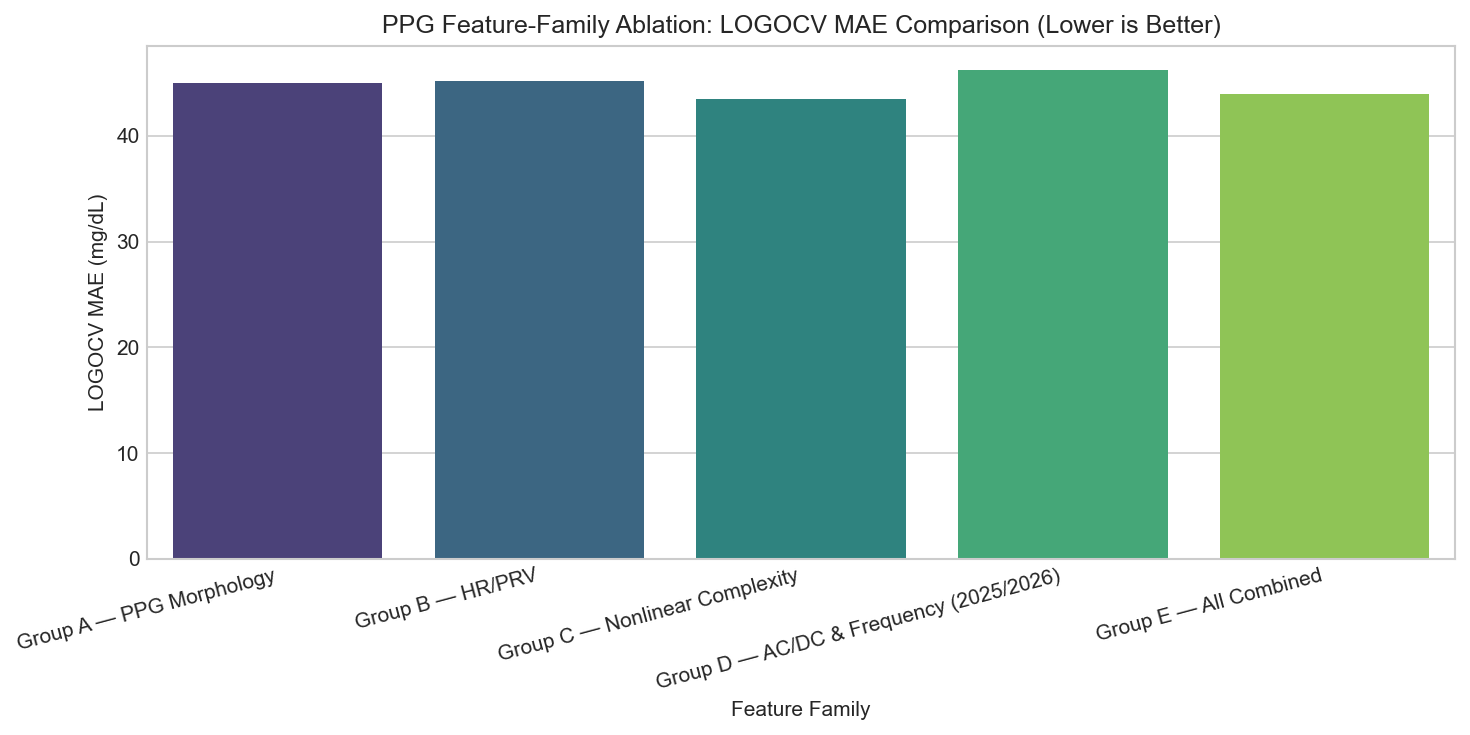

In [5]:
# Cell 5: Run Feature-Family Ablation Study

feature_families = {
    "Group A — PPG Morphology": group_a_cols,
    "Group B — HR/PRV": group_b_cols,
    "Group C — Nonlinear Complexity": group_c_cols,
    "Group D — AC/DC & Frequency (2025/2026)": group_d_cols,
    "Group E — All Combined": all_cols
}

all_ablation_results = []

for family_name, cols in feature_families.items():
    if len(cols) == 0:
        continue
    print(f"Evaluating {family_name} ({len(cols)} features)...")
    res_df = evaluate_feature_group(df_all, cols, family_name)
    all_ablation_results.append(res_df)

df_ablation_all = pd.concat(all_ablation_results, ignore_index=True)

# Select best model for each family based on MAE
summary_rows = []
for family_name, group_df in df_ablation_all.groupby("Group", sort=False):
    best_row = group_df.loc[group_df["MAE"].idxmin()]
    summary_rows.append({
        "Feature Family": family_name,
        "Best Model": best_row["Model"],
        "LOGOCV MAE (mg/dL)": best_row["MAE"],
        "LOGOCV RMSE": best_row["RMSE"],
        "LOGOCV R²": best_row["R2"]
    })

df_summary = pd.DataFrame(summary_rows)
print("\n=======================================================")
print("          FEATURE-FAMILY ABLATION STUDY RESULTS         ")
print("=======================================================")
print(df_summary.to_string(index=False))

# Plot comparative bar plot
plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary, x="Feature Family", y="LOGOCV MAE (mg/dL)", palette="viridis")
plt.xticks(rotation=15, ha="right")
plt.title("PPG Feature-Family Ablation: LOGOCV MAE Comparison (Lower is Better)")
plt.ylabel("LOGOCV MAE (mg/dL)")
plt.tight_layout()
plt.show()
